<a href="https://colab.research.google.com/github/Flottohs/Phase-1/blob/main/GithubFletchAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prep

1. Data Pipeline (The "Loader")
Before the model can learn, you have to turn your chat.txt into something math-compatible.

Cleaning: Use Regex to remove timestamps and system messages.

Labeling: Format the text into a single string like:
[FRIEND]: hello [HAYDEN]: yo [END] [FRIEND]: u up? [HAYDEN]: barely lol [END]

Vocab: Create your stoi (string-to-int) and itos (int-to-string) mappings.

Tensors: Convert the entire string into a torch.long tensor.

###Imports

In [ ]:
import random
import os
import json
import re
import logging
import time
from datetime import datetime
import pandas as pd
import numpy as np
from tqdm import tqdm
import zipfile
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F

# --- HYPERPARAMETERS & CONFIG ---
YOUR_NAME = "Yourname"
CONTEXT_SIZE = 3
MIN_REPLY_LEN = 6

batch_size = 64       # Unified batch size
block_size = 256      # Unified block size
epochs = 10000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_emb = 384
n_heads = 6
n_layer = 6
dropout = 0.3

print(f"Using device: {device}")

Using device: cuda


#Alter for yourself.

In [ ]:
# --- DATA DOWNLOAD ---
TOKEN = "Your Github private token"
api_url = "Your_API"
headers = {
    "Authorization": f"Bearer {TOKEN}",
    "Accept": "application/vnd.github.v3+json"
}

response = requests.get(api_url, headers=headers)
if response.status_code == 200:
    items = response.json()
    for item in items:
        if item['type'] == 'file':
            file_name = item['name']
            download_url = item['download_url']
            print(f"Downloading {file_name}...")
            file_response = requests.get(download_url, headers=headers)
            if file_response.status_code == 200:
                with open(file_name, 'wb') as f:
                    f.write(file_response.content)
            else:
                print(f"Failed to download {file_name}")
else:
    print(f"Failed GitHub Fetch! Status Code: {response.status_code}")

In [ ]:
# --- READ CHAT LOGS ---
# (Assuming files are successfully downloaded or exist locally)
chat_files = ['Your_chatfiles']
text = "your_text"

for file in chat_files:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            content = f.read()
            text += content + "\n"
    except FileNotFoundError:
        print(f"Warning: {file} not found, skipping...")


In [ ]:
# --- DATA PROCESSING ---
def clean_message(msg):
    msg = msg.replace("\u200e", "")
    system_patterns = [r"You deleted this message\.", r"Voice call.*", r"Video call.*", r"Missed call.*", r"This message was deleted\."]
    for pattern in system_patterns:
        msg = re.sub(pattern, "", msg, flags=re.IGNORECASE)
    msg = msg.strip()
    if len(msg.split()) == 1 and len(msg) <= 3:
        return ""
    return msg

def parse_chat(raw_text):
    pattern = r"\[\d{2}/\d{2}/\d{4}, \d{2}:\d{2}:\d{2}\] (.*?): (.*)"
    messages = []
    for line in raw_text.split("\n"):
        match = re.match(pattern, line)
        if match:
            speaker, msg = match.groups()
            speaker = "You" if speaker == YOUR_NAME else "User"
            msg = clean_message(msg)
            if msg:
                messages.append((speaker, msg))
    return messages

def merge_messages(messages):
    merged = []
    for speaker, msg in messages:
        if merged and merged[-1][0] == speaker:
            merged[-1] = (speaker, merged[-1][1] + " " + msg)
        else:
            merged.append((speaker, msg))
    return merged

def is_good_reply(msg):
    weak = ["ok", "k", "kk", "yh", "yeah", "thanks", "ok thanks", "wanna", "no", "yes"] #add other slang or small words as needed
    return len(msg) >= MIN_REPLY_LEN and msg.lower() not in weak

def build_pairs(messages):
    pairs = []
    for i in range(len(messages)):
        speaker, msg = messages[i]
        if speaker != "You" or not is_good_reply(msg):
            continue
        start = max(0, i - CONTEXT_SIZE)
        context = messages[start:i]
        if not context or not any(s == "User" for s, _ in context) or context[-1][0] != "User":
            continue

        same_speaker_streak = 1
        for j in range(len(context) - 1, 0, -1):
            if context[j][0] == context[j-1][0]:
                same_speaker_streak += 1
            else:
                break
        if same_speaker_streak >= 3:
            continue

        clean_context = []
        for s, m in reversed(context):
            clean_context.insert(0, (s, m))
            if s == "User":
                break

        context_text = "\n".join([f"{s}: {m}" for s, m in clean_context])
        pair = f"{context_text}\nYou: {msg}\n"
        if pairs and pair == pairs[-1]:
            continue
        pairs.append(pair)
    return pairs

pairs = build_pairs(merge_messages(parse_chat(text)))
print("Data processed. Total pairs:", len(pairs))

full_training_text = "".join(pairs)
chars = sorted(list(set(full_training_text)))
vocab_size = len(chars)
print(f"Vocab size: {vocab_size}")

Data processed. Total pairs: 2719
Vocab size: 208


###Create dictionary

In [ ]:

stoi = {v: i for i, v in enumerate(chars)}
itos = {i: v for i, v in enumerate(chars)}

def encode(stringinput:str):
    return [stoi[word] for word in stringinput]

def decode(values:list):
    return ''.join([itos[value] for value in values])

data = torch.tensor(encode(full_training_text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n].to(device)
val_data = data[n:].to(device)


###Vocab

In [ ]:

stoi = {v: i for i, v in enumerate(chars)}
itos = {i: v for i, v in enumerate(chars)}


In [ ]:
def encode(stringinput:str):
  newlist = []
  for word in stringinput:
    newlist.append(stoi[word])

  return newlist

def decode(values:list):

  newlist = []
  for value in values:
    newlist.append(itos[value])
  return ''.join(newlist)


data = torch.tensor(encode(full_training_text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n].to(device)
val_data = data[n:].to(device)

def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i: i + block_size] for i in ix])
    y = torch.stack([data_split[i+1: i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)




#Model


2. The Model Architecture (The "Brain")
You’ll want to build a Decoder-only Transformer. In PyTorch, you should structure your classes like this:

class SelfAttention: The core mechanism where tokens look at previous tokens.

class MultiHeadAttention: Running multiple attention "heads" in parallel so the bot can pick up on different vibes (e.g., one head for slang, one for grammar).

class FeedForward: A simple linear layer + ReLU to let the model "think" about what it just saw.

class Block: Combines Attention and FeedForward with LayerNorm.

class HaydenTransformer: The master class that ties it all together with an Embedding Table and a Language Modeling Head.

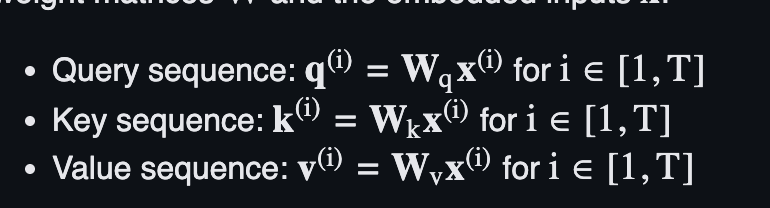

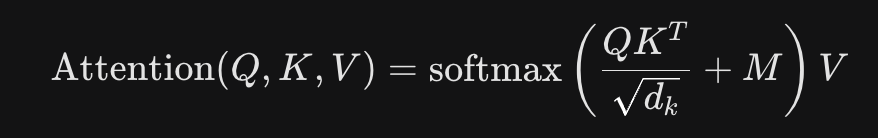


(B, T, C) simply means your neural network is currently processing a Batch of B sentences at once, where each sentence has a sequence length of T words (over Time), and every single word is represented by a list of C numbers (Channels).

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self,head_size):
        super().__init__()
        self.key = nn.Linear(n_emb, head_size, bias=False)
        self.query = nn.Linear(n_emb, head_size, bias=False)
        self.value = nn.Linear(n_emb, head_size, bias=False)

        #allows us to create a buffer under a name we chose, works differently from regular attributes, you can chose if you want it to be in your models state dict by changing on and off persistent
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))


        #Randomly at a set rate basically grabs elements of the array and sets them to zero. This is done to prevent overfitting/memorizing of the training data
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        #Batchsize, token sequence length, channel dimensions
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)

        # Compute attention scores ("affinities")
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1]**-0.5)
        #use the masked fill method applicable on tensors, and use your masked fill which you created under register buffer, which we call tril

        #The code self.tril[:T, :T] == 0 creates a boolean mask (True/False). It marks the "upper triangle" (the zeros) as True. These represent the "future" tokens that the current token isn't allowed to see.
        #it replaces these zeros with infinity, which when softmaxed goes back to zero
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim = -1)

        wei = self.dropout(wei)


        #wei is just filled with relational values, saying how much each thing relates by value, value matrix is used to say well its relating x to y actually, so it actually has meaning rather than just a value of relation.
        #we use a value matrix instead of x likeyou would think because then the model can actaully learn what everything means, adn is able to adjust it
        out = wei @ v




        return out






In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self,n_heads,head_size):
    #use module list as it plugs everything in in parralel, more efficient and because its not sequentially inputted one layer to the next
    super().__init__()
    self.heads = nn.ModuleList([SelfAttention(head_size) for _ in range(n_heads)])

    #allow the layer to think on the final outputs of the heads
    #i thought why dont you just have a self attentoin layer ontop of it, but i guess talking more is bad idrk ill figure it out more with experimets once this is complete
    self.proj = nn.Linear(n_emb,n_emb)


  def forward(self,x):
    out = torch.cat([h(x) for h in self.heads], dim = -1)
    out = self.proj(out)
    return out




In [ ]:
class FeedForward(nn.Module):


  def __init__(self,n_emb):
    super().__init__()
    self.stack = nn.Sequential(
        nn.Linear(in_features = n_emb, out_features = n_emb * 4),
        nn.ReLU(),
        nn.Linear(in_features = 4 * n_emb, out_features = n_emb),
#no ReLU, want to be able to be able to be negative
    )

  def forward(self,x):
    return self.stack(x)

In [ ]:
class Block(nn.Module):

  def __init__(self,n_emb,n_heads):
    super().__init__()

    head_size = n_emb // n_heads

    self.sa = MultiHeadAttention(n_heads,head_size)
    self.ffd = FeedForward(n_emb)
    self.ln1 = nn.RMSNorm(n_emb)
    self.ln2 = nn.RMSNorm(n_emb)

    #In the beginning, LayerNorm absolutely "messes up" the raw values, but the model doesn't care about the raw values—it cares about the information they represent. Because LayerNorm is a consistent, predictable "smudge," the model learns to work through it.
  def forward(self,x):

    x = x+self.sa(self.ln1(x))

    x = x + self.ffd(self.ln2(x))

    return x





In [ ]:
class Fletchai(nn.Module):


  def __init__(self,vocab_size):
    super().__init__()
    #create the models own embeddings, so it can learn it and use it, need positoinal so you can see how the embeddings relate to eachother, in its own space
    self.embeddings = nn.Embedding(vocab_size,n_emb)

    self.positional_emb = nn.Embedding(block_size,n_emb)

    self.blocks = nn.Sequential(*[Block(n_emb, n_heads=n_heads) for _ in range(n_layer)])


    self.ln_final = nn.LayerNorm(n_emb)


    self.decoder = nn.Linear(n_emb,vocab_size)


  def forward(self, idx, targets = None):
    #print('good check1')


    #batch num, token sequence length
    #looking at singular value in x
    B,T = idx.shape
    '''# Batch 1: "The Cat Sat" -> [1, 2, 3]
# Batch 2: "Cat Sat Mat" -> [2, 3, 4]

idx = [
  [1, 2, 3],
  [2, 3, 4]
]'''
    #B (Batch Size): How many independent examples we process in parallel (e.g., 32 sentences).

    #T (Time/Sequence Length): How many tokens are in each example (e.g., a sequence of 8 words).

    #At this stage, each "token" is just a single integer (an index) pointing to a word in your vocabulary. There is no "Channel" dimension yet because the computer hasn't turned those integers into rich vectors (embeddings) yet.

    emb = self.embeddings(idx)
    pos_emb = self.positional_emb(torch.arange(T,device = device))
    #why do you add them together, they are separate entitiies?

    x = emb + pos_emb

    x = self.blocks(x)
    x = self.ln_final(x)

    logits = self.decoder(x)

    #print('pre target dealer')

    #print(f"DEBUG: targets type is {type(targets)}, value is {targets}")
    if targets is None:
      loss = None

    else:



      '''logits = [
        Batch 1
          [
        [4.5, 0.1, -1.2, 0.5],  # Scores for "The" (Pos 0)
        [0.2, 3.8, 1.1, -0.5],  # Scores for "Cat" (Pos 1)
        [-1.0, 0.5, 5.2, 2.1]   # Scores for "Sat" (Pos 2)
         ],
           Batch 2
          [
            [0.1, 4.1, 0.3, 0.8],   # Scores for "Cat" (Pos 0)
            [-0.5, 0.2, 3.9, 1.5],  # Scores for "Sat" (Pos 1)
            [0.9, -1.2, 0.4, 4.8]   # Scores for "Mat" (Pos 2)
          ]
        ]'''
      B,T,C = logits.shape#The data gains the C (Channel/Embedding) dimension the moment it passes through self.embeddings(idx).



      flattened_logits = logits.view(B*T, C)


      '''flattened_logits = [
    [4.5, 0.1, -1.2, 0.5], # Word 1
    [0.2, 3.8, 1.1, -0.5], # Word 2
    [-1.0, 0.5, 5.2, 2.1], # Word 3
    [0.1, 4.1, 0.3, 0.8],  # Word 4
    [-0.5, 0.2, 3.9, 1.5], # Word 5
    [0.9, -1.2, 0.4, 4.8]  # Word 6
]'''
      flattened_targets = targets.view(B*T)


      '''# These are just the "Correct Answer" IDs for the 6 positions above
flattened_targets = [2, 3, 4, 3, 4, 1]'''

      loss = F.cross_entropy(flattened_logits, flattened_targets)

    return logits, loss







  def generate(self, idx, max_new_tokens, temperature=1.0):
    for _ in range(max_new_tokens):
        # Crop idx to the last block_size tokens so positional embeddings don't overflow
        idx_cond = idx[:, -block_size:]

        # EXPLICITLY pass targets=None to avoid the 'bool' error in forward()
        logits, _ = self(idx_cond, targets=None)

        # Focus only on the last time step
        logits = logits[:, -1, :] # (B, C)

        # Apply scaling for "sauciness"
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1) # (B, C)

        # Sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)

        # Append to the running sequence
        idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)

    return idx


#Train
3. The Training Loop (The "Learning")This is where the model repeats the "Predict, Check, Fix" cycle thousands of times.Hyperparameters: Define your batch_size, block_size (context length), and learning_rate.Optimizer: Use torch.optim.AdamW.Loss Function: Use F.cross_entropy.The Loop:Get a batch of data ($x$ is the input, $y$ is the next character).Forward pass: Get the model's guess.Calculate loss (how far off was the guess?).Backward pass: loss.backward() to calculate gradients.Step: optimizer.step() to update the weights.

Low Loss (Good): 0.01 to 0.20

The model is very confident and usually correct. A loss of 0.10 means the model is roughly 90% sure of the right answer.

Moderate Loss: 0.50 to 0.70

The model is "leaning" toward the right answer but is hesitant.

High Loss (Bad): 2.30+

For a 10-category problem (like digit recognition), a loss of 2.30 is what you get if the model is just guessing randomly.

In [ ]:
start_time = time.time()
print("Starting Train")

fl_model = Fletchai(vocab_size=vocab_size).to(device)
optimizer = torch.optim.AdamW(fl_model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

for epoch in range(epochs):
    xb, yb = get_batch('train')


    logits, loss = fl_model(xb, yb)


    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Fixed: epoch % 100 instead of epochs % 100
    if epoch % 100 == 0:
        fl_model.eval()
        torch.inference_mode():

          x_valb, y_valb = get_batch('val')
          val_logits, val_loss = fl_model(x_valb, y_valb)

        fl_model.train()
        elapsed = (time.time() - start_time) / 60
        # Fixed: Iter {epoch} instead of Iter {iter}
        print(f"Epoch {epoch}: TrainLoss {loss.item():.4f} | ValLoss {val_loss.item():.4f} | {elapsed:.1f} mins elapsed")

print("Training complete!")

Starting Train
Epoch 0: TrainLoss 5.4819 | ValLoss 5.4724 | 0.0 mins elapsed


KeyboardInterrupt: 

In [ ]:
# --- SAVE & LOAD ---
PATH = "fl_model_weights.pth"
torch.save(fl_model.state_dict(), PATH)
print(f"Model weights saved to {PATH}")

#The Inference Script
Once trained, the model doesn't just "talk." You have to give it a starting prompt and let it generate characters one by one.

Sampling: Use torch.multinomial to pick the next character based on the model's predicted probabilities.

Temperature: Add a "Temperature" setting.

Low Temp = Bot is safe and boring.

High Temp = Bot is creative but might make typos.

In [ ]:

# Re-load model (dynamically using active vocab_size so it doesn't crash)
model = Fletchai(vocab_size=vocab_size).to(device)
model.load_state_dict(torch.load(PATH, map_location=device))
model.eval()


In [ ]:

# --- INFERENCE LOOP ---
print("-" * 50)
print("Fletchai is online! Type 'quit' or 'exit' to stop.")

# Fixed: Wrapped input in float() so math division works
try:
    TEMP = float(input("How saucy do you want Fletchai to be? Give a value from 0.5-1.5: "))
except ValueError:
    print("Invalid number, defaulting to 1.0")
    TEMP = 1.0

chat_history = ""

while True:
    user_input = input("User: ")

    if user_input.lower() in ['quit', 'exit', "i am paul muad'dib attredies, duke of arrakis"]:
        print("Catch you on the flip side home dawg")
        break

    chat_history += f"User: {user_input}\nYou: "
    context_ints = [stoi[c] for c in chat_history if c in stoi]
    x = torch.tensor(context_ints, dtype=torch.long, device=device).unsqueeze(0)

    y = model.generate(x, max_new_tokens=150, temperature=TEMP)

    out_ints = y[0].tolist()
    full_response = ''.join([itos[i] for i in out_ints])
    new_bot_text = full_response[len(chat_history):]

    if "\nUser:" in new_bot_text:
        new_bot_text = new_bot_text.split("\nUser:")[0]

    print(f"Fletchai: {new_bot_text.strip()}")
    chat_history += new_bot_text.strip() + "\n"

    max_history = block_size - 150
    if len(chat_history) > max_history:
        chat_history = chat_history[-max_history:]